# Human Activity Recognition — praktikandi töö

Nimi: **Maksim**  
Kuupäev: **15.08.2026**

## Goal

Eesmärk on ennustada nutitelefoni sensoriaknast inimese tegevust. Põhimõõdik on **macro-F1** ning valideerimine peab hoidma sama inimese aknad alati ühes foldis.

## Setup

Käivita notebook algusest lõpuni. Hoia kõik olulised parameetrid selles sektsioonis.

In [1]:
from pathlib import Path
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    confusion_matrix, f1_score,
)
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
N_SPLITS = 5
random.seed(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid")

In [2]:
from pathlib import Path

#Määra kus Pathiks UCI HAR Dataset asukoht
#Näide
DATA_DIR = Path(
    r"/Users/maksimp/Documents/HAR_praktika/data/UCI HAR Dataset"
)

required_file = DATA_DIR / "train" / "X_train.txt"

if not required_file.exists():
    raise FileNotFoundError(
        f"Faili ei leitud: {required_file}\n"
        f"Kontrolli andmestiku lahtipakkimist."
    )

print(f"Andmestik: {DATA_DIR}")

Andmestik: /Users/maksimp/Documents/HAR_praktika/data/UCI HAR Dataset


## Steps

### 1. Laadi ja kontrolli andmed

Laadi `X`, `y` ja subjektide ID-d. Lisa unikaalsed tunnusenimed ning kontrolli kujusid, puuduvaid väärtusi ja klassijaotust. Selgita, mida üks rida esindab.

In [3]:
# TODO: andmete laadimine ja kvaliteedikontroll
features = pd.read_csv(DATA_DIR / "features.txt", sep=r"\s+", header=None, names=["idx", "feature"])
feature_names = features["feature"].tolist()

def make_unique(names):
    seen = {}
    out = []
    for n in names:
        if n not in seen:
            seen[n] = 0
            out.append(n)
        else:
            seen[n] += 1
            out.append(f"{n}__{seen[n]}")
    return out

feature_names_unique = make_unique(feature_names)

X_train = pd.read_csv(DATA_DIR / "train" / "X_train.txt", sep=r"\s+", header=None, names=feature_names_unique)
y_train = pd.read_csv(DATA_DIR / "train" / "y_train.txt", header=None, names=["activity_id"]).squeeze("columns")
subject_train = pd.read_csv(DATA_DIR / "train" / "subject_train.txt", header=None, names=["subject"]).squeeze("columns")

X_test = pd.read_csv(DATA_DIR / "test" / "X_test.txt", sep=r"\s+", header=None, names=feature_names_unique)
y_test = pd.read_csv(DATA_DIR / "test" / "y_test.txt", header=None, names=["activity_id"]).squeeze("columns")
subject_test = pd.read_csv(DATA_DIR / "test" / "subject_test.txt", header=None, names=["subject"]).squeeze("columns")

activity_labels = pd.read_csv(DATA_DIR / "activity_labels.txt", sep=r"\s+", header=None, names=["activity_id", "activity_name"])
label_map = dict(zip(activity_labels["activity_id"], activity_labels["activity_name"]))
y_train_named = y_train.map(label_map)
y_test_named = y_test.map(label_map)

In [4]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0
assert len(X_train) == len(y_train) == len(subject_train)
assert len(X_test) == len(y_test) == len(subject_test)

print(y_train_named.value_counts())
print("Unique in train:", subject_train.nunique())
print("Unique in test:", subject_test.nunique())
print("train/test:", set(subject_train) & set(subject_test))

X_train shape: (7352, 561)
X_test shape: (2947, 561)
activity_id
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64
Unique in train: 21
Unique in test: 9
train/test: set()


Üks rida = üks 2.56-sekundiline sensoriaken (accelerometer + gyroscope) ühe subjekti kohta ühe konkreetse tegevuse ajal, esindatuna 561 aja- ja sagedusdomeeni tunnusega. Klassijaotus on kergelt ebatasakaalus (LAYING kõige rohkem, WALKING_DOWNSTAIRS kõige vähem), train ja test subjektid ei kattu.

### 2. Kavanda leakage'ita valideerimine

Kasuta subjektigruppe. Näita koodiga, et train- ja validation-subjektide ühisosa on igas foldis tühi.

**Põhjendus:** Aknad kattuvad ~50% ulatuses, mistõttu naaberaknad samalt subjektilt on väga sarnased — juhuslik reasplit paneks peaaegu identsed aknad korraga train- ja val-hulka, mis annaks ülehinnatud tulemuse. Lisaks on igal subjektil oma liikumisstiil, mistõttu peab valideerimine testima üldistumist uutele inimestele, mitte uutele akendele samalt inimeselt. Seetõttu kasutan StratifiedGroupKFold-i subjekti gruppidena (groups=subject_train), mis tagab, et iga subjekti kõik aknad jäävad tervikuna kas train- või val-hulka. Kontroll ülal näitab, et igas foldis on subjektide ühisosa tühi (overlap=0).


In [5]:
# TODO: StratifiedGroupKFold ja leakage'i kontroll
from sklearn.model_selection import StratifiedGroupKFold

N_SPLITS = 5
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

folds = list(cv.split(X_train, y_train, groups=subject_train))

for i, (tr_idx, val_idx) in enumerate(folds):
    subj_tr = set(subject_train.iloc[tr_idx])
    subj_val = set(subject_train.iloc[val_idx])
    overlap = subj_tr & subj_val
    print(f"Fold {i}: train subjects={len(subj_tr)}, val subjects={len(subj_val)}, overlap={len(overlap)}")
    assert len(overlap) == 0, f"Leakage in fold {i}!"

Fold 0: train subjects=17, val subjects=4, overlap=0
Fold 1: train subjects=17, val subjects=4, overlap=0
Fold 2: train subjects=16, val subjects=5, overlap=0
Fold 3: train subjects=17, val subjects=4, overlap=0
Fold 4: train subjects=17, val subjects=4, overlap=0


### 3. Treeni baasmudel

Kasuta näiteks `DummyClassifier`-it ja mõõda sama ristvalideerimisega macro-F1.

In [6]:
# TODO: baasmudel ja selle ristvalideerimise tulemus
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate

dummy = DummyClassifier(strategy="stratified", random_state=SEED)

dummy_scores = cross_validate(
    dummy, X_train, y_train,
    cv=cv, groups=subject_train,
    scoring="f1_macro",
    n_jobs=-1,
)
print("Dummy macro-F1 per fold:", dummy_scores["test_score"])
print("Dummy macro-F1 mean ± std:", dummy_scores["test_score"].mean(), "±", dummy_scores["test_score"].std())

Dummy macro-F1 per fold: [0.17725083 0.1555114  0.18327698 0.1638935  0.16696911]
Dummy macro-F1 mean ± std: 0.16938036210736732 ± 0.009831868310906159


### 4. Koosta klassifikatsiooni pipeline

Põhjenda preprocessing, mudel, feature engineering/selection ja mõõdik.

**Põhjendus:** TODO

In [7]:
# TODO: Pipeline ja mudeli parameetrid
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

clf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        C=1.0,
        random_state=SEED,
    )),
])

Kas ja miks skaleerin tunnuseid. Kasutan StandardScaler-it. 561 tunnust on signaali statistikud (mean, std, energia, korrelatsioon, sageduskomponendid jne), millel on väga erinevad skaalad ja mõõtühikud. Logistiline regressioon (ja samuti SVM) optimeerib funktsiooni, mis on tundlik sisendi skaalale — regulariseerimine ja gradient-põhine optimeerimine töötavad ebakorrektselt, kui tunnused on erinevas vahemikus, sest suurema absoluutväärtusega tunnused domineerivad. Puu-põhised mudelid (nt random forest) skaleerimist ei vaja, kuid kuna valisin lineaarse mudeli, on skaleerimine kohustuslik.

Miks valisin just selle mudeli. Valisin LogisticRegression-i. See sobib, sest: andmestik on tabelikujuline, mitte pilt ega järjestus, seega süvaõpe pole vajalik; tunnused on juba kvaliteetselt inseneritud aja- ja sagedusdomeeni statistikud — algses UCI HAR uurimuses näitas lineaarne SVM samadel tunnustel tugevaid tulemusi, mis viitab, et lineaarne mudel peaks siin hästi töötama; LogisticRegression on kiire, interpreteeritav, stabiilne ja lihtsalt põhjendatav — vähe hüperparameetreid, mida code review'l selgitada. Alternatiivina väärib katsetamist SVC(kernel="rbf"), mis võib olla täpsem tänu mittelineaarsusele sarnaste klasside vahel (nt SITTING vs STANDING), kuid on aeglasem treenida.

Kas feature engineering või feature selection on vajalik. Baasversioonis ei ole see kohustuslik — tunnused on juba kvaliteetse feature engineering'u tulemus (UCI valmis andmestik, mitte toorsignaal). Valikuliselt võiks lisada PCA või SelectKBest, et vähendada multikollineaarsust (paljud 561 tunnusest on omavahel tugevalt korreleeritud, nt vector magnitude tunnused tulenevad X/Y/Z komponentidest), kuid see ei ole ülesande nõue, vaid täiendav eksperiment võrdluseks.

Miks valitud F1-variant sobib klassijaotusega. Kasutan põhimõõdikuna macro-F1, sest see keskmistab F1-skoori klasside lõikes nende suurust arvestamata — see tähendab, et halb tulemus nii sagedasel kui harval klassil mõjutab skoori võrdselt. See on oluline, sest klassijaotus ei ole täiesti tasakaalus (nt LAYING esineb sagedamini kui WALKING_DOWNSTAIRS) ning rakenduslikust vaatest on kõik kuus tegevust võrdselt olulised (nt fitness/health tracking kontekstis), mitte ainult domineerivad klassid. Accuracy ja weighted-F1 võivad varjata halba tulemust vähem esindatud klassidel, kui mudel ennustab hästi vaid enamusklasse.

### 5. Loo ning hinda mudelit subjektipõhise ristvalideerimisega

Näita foldide macro-F1, weighted-F1 ja accuracy, samuti keskmist ja standardhälvet.

In [8]:
# TODO: cross_validate ja tulemuste tabel
scoring = {
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted",
    "accuracy": "accuracy",
}

cv_results = cross_validate(
    clf_pipeline, X_train, y_train,
    cv=cv, groups=subject_train,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False,
)

results_df = pd.DataFrame({
    "fold": range(N_SPLITS),
    "macro_f1": cv_results["test_macro_f1"],
    "weighted_f1": cv_results["test_weighted_f1"],
    "accuracy": cv_results["test_accuracy"],
})
print(results_df)
print(results_df[["macro_f1", "weighted_f1", "accuracy"]].agg(["mean", "std"]))

   fold  macro_f1  weighted_f1  accuracy
0     0  0.952294     0.954903  0.955497
1     1  0.913421     0.910032  0.909877
2     2  0.952663     0.953967  0.954072
3     3  0.881107     0.885015  0.883263
4     4  0.976840     0.977583  0.977569
      macro_f1  weighted_f1  accuracy
mean  0.935265     0.936300  0.936056
std   0.037853     0.037692  0.038400


Mudel (LogisticRegression + StandardScaler) saavutab keskmise macro-F1 = 0.935 ± 0.038, mis on drastiliselt parem kui baseline (DummyClassifier, macro-F1 ≈ 0.169) — mudel õpib selgelt sisulist signaali. Foldide vaheline varieeruvus (0.881–0.977) viitab sellele, et mudeli kvaliteet sõltub osaliselt konkreetsetest subjektidest valideerimishulgas — see on subjekti-põhise CV loomulik omadus ja annab realistlikuma hinnangu üldistumisele uutele inimestele kui juhuslik reasplit annaks.

### 6. Treeni lõplik mudel ja hinda testkomplektil

Testkomplekti kasuta alles pärast mudelivalikut.

In [9]:
# TODO: fit kõigil treeningandmetel; macro-F1, weighted-F1, accuracy ja classification report

clf_pipeline.fit(X_train, y_train)

y_pred_test = clf_pipeline.predict(X_test)

test_macro_f1 = f1_score(y_test, y_pred_test, average="macro")
test_weighted_f1 = f1_score(y_test, y_pred_test, average="weighted")
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"Test macro-F1:    {test_macro_f1:.4f}")
print(f"Test weighted-F1: {test_weighted_f1:.4f}")
print(f"Test accuracy:    {test_accuracy:.4f}")
print(classification_report(y_test, y_pred_test, target_names=activity_labels["activity_name"]))

Test macro-F1:    0.9544
Test weighted-F1: 0.9545
Test accuracy:    0.9545
                    precision    recall  f1-score   support

           WALKING       0.94      0.99      0.97       496
  WALKING_UPSTAIRS       0.96      0.95      0.95       471
WALKING_DOWNSTAIRS       0.99      0.94      0.96       420
           SITTING       0.97      0.87      0.92       491
          STANDING       0.89      0.97      0.93       532
            LAYING       1.00      0.99      0.99       537

          accuracy                           0.95      2947
         macro avg       0.96      0.95      0.95      2947
      weighted avg       0.96      0.95      0.95      2947



### 7. Analüüsi vigu

Joonista rea kaupa normaliseeritud confusion matrix ja leia suurimad klassidevahelised eksimused.

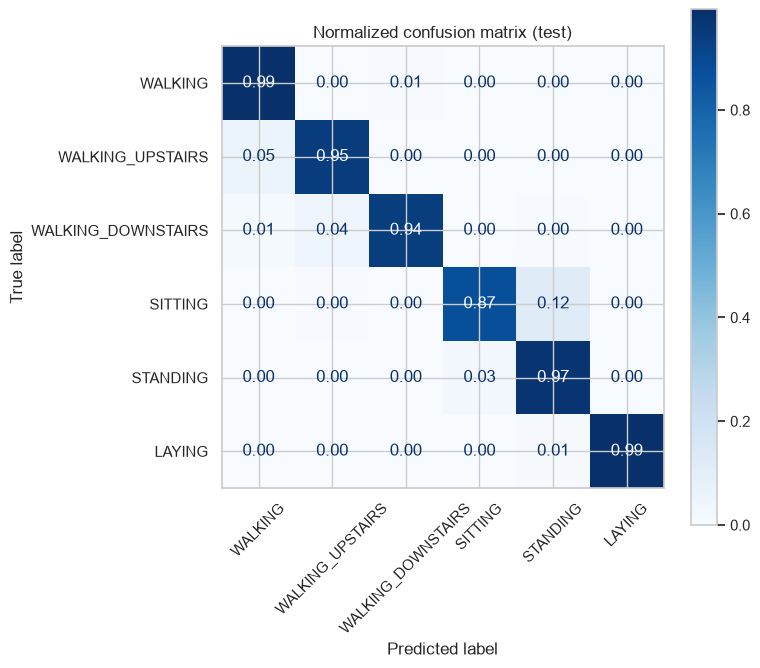

SITTING             STANDING            0.120163
WALKING_UPSTAIRS    WALKING             0.050955
WALKING_DOWNSTAIRS  WALKING_UPSTAIRS    0.040476
STANDING            SITTING             0.026316
WALKING_DOWNSTAIRS  WALKING             0.014286
dtype: float64

In [10]:
# TODO: confusion matrix ja suurimate segiajamiste tabel
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels_order = activity_labels["activity_name"].tolist()
cm = confusion_matrix(
    y_test.map(label_map), pd.Series(y_pred_test).map(label_map),
    labels=labels_order, normalize="true",
)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format=".2f")
plt.title("Normalized confusion matrix (test)")
plt.tight_layout()
plt.show()

 
cm_df = pd.DataFrame(cm, index=labels_order, columns=labels_order)
np.fill_diagonal(cm_df.values, 0)
top_confusions = cm_df.stack().sort_values(ascending=False).head(5)
print(top_confusions)

## Checks

- [x] Train- ja testsubjektid ei kattu.
- [x] Üheski CV-foldis ei kattu train- ja validation-subjektid.
- [x] Preprocessing on pipeline'is.
- [x] Seed ja mudeli parameetrid on nähtavad.
- [x] Notebook töötab `Restart Kernel and Run All` käsuga.

## Next Steps

1. **Kõige sagedamini segiaetud klassid:** 
SITTING → STANDING (12% tegelikest SITTING juhtudest ennustati STANDING'uks), STANDING → SITTING (3% vastupidises suunas). Väiksem segadus esineb ka WALKING_UPSTAIRS/WALKING_DOWNSTAIRS ja WALKING vahel (4–5%).
2. **Miks need klassid võivad sarnased olla:** 
SITTING ja STANDING on mõlemad staatilised olekud — sensor ei liigu kummalgi juhul oluliselt, erinevus peitub peamiselt peene kehaasendi/kaldenurga infos, mida lineaarne mudel raskemini eristab kui selget dünaamikat kõndimisklassides.
3. **Kaks järgmist parandust:** 
Katsetada mittelineaarset mudelit (SVC(kernel="rbf") või RandomForestClassifier), et paremini eraldada staatilisi klasse (SITTING/STANDING), mille eristamine nõuab peenemaid, mittelineaarseid mustreid.
Analüüsida, millised konkreetsed tunnused SITTING ja STANDING kõige rohkem eristavad (nt permutation importance), ja kaaluda hierarhilist lähenemist — kõigepealt "static vs dynamic" binaarne klassifikaator, seejärel eraldi mudel staatiliste/dünaamiliste klasside sees.

4. **Olulised piirangud:** 
Väike subjektide arv — ainult 30 inimest kokku (21 train, 9 test). Mudeli üldistumine uutele inimestele on hinnatud vaid 9 test-subjekti peal, mis on statistiliselt väike valim — reaalses maailmas (rohkemate/mitmekesisemate kasutajatega) võib tulemus erineda.
Kontrollitud eksperimendi tingimused — andmed koguti vöökohale kinnitatud telefoniga kontrollitud katsetingimustes. Reaalses kasutuses (telefon taskus, käes, erineval kinnitusviisil) võib sensorisignaal ja seega tunnuste jaotus oluliselt erineda — mudel ei pruugi otse üldistuda.
Piiratud mudelivalik — katsetatud on vaid üks mudel (LogisticRegression) põhjaliku hüperparameetrite otsinguta, vastavalt ülesande nõudele. Teised mudelid (nt RBF-SVM, ansamblid) võivad anda parema tulemuse, eriti SITTING/STANDING eristamisel.